<a href="https://colab.research.google.com/github/DJReazy/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if it is linear in the coefficients, meaning each variable is multiplied by a constant and then added together. The variables themselves can be transformed (like squared), but the coefficients are not multiplied together.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient shows how much the outcome changes compared to the baseline group (when the dummy = 0). The intercept represents the baseline, and the dummy coefficient is the difference from that baseline when the dummy = 1.

3. Can linear regression be used for classification? Explain why, or why not.

It can, but it’s not a good idea. Linear regression can give predictions outside of 0–1, which doesn’t make sense for probabilities.

4. What are signs that your linear model is over-fitting?

*   Works very well on training data but poorly on test data
*   Too many variables compared to data points
*   Coefficients are very large or unstable

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when variables are highly correlated, so it’s hard to separate their effects. In 2-stage least squares, you first predict one variable using others, then use that predicted version in the main regression to reduce the problem.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add things like
𝑥^2, logs, or interaction terms. This lets the model capture curves, even though it’s still linear in the coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

It tells you how much y changes when x increases by 1, holding other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

Train/test split uses one split of the data.
k-fold splits the data into multiple parts and tests multiple times, so it’s more reliable.

9. How is the $k$ in $k$-fold cross validation typically selected?

Usually 5 or 10. Bigger
k is more accurate but takes longer.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [3]:
import pandas as pd

df = pd.read_csv("/content/Q1_clean.csv")

# fix column name (spaces are annoying)
df = df.rename(columns={"Review Scores Rating": "Rating"})
df.head()

,Price,Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [5]:
if 'Neighbourhood ' in df.columns:
    df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True)

group_means = df.groupby("Neighbourhood")[["Price", "Rating"]].mean()
print(group_means)

                    Price     Rating
Neighbourhood                       
Bronx           75.276498  91.654378
Brooklyn       127.747378  92.363497
Manhattan      183.664286  91.801496
Queens          96.857233  91.549057
Staten Island  146.166667  90.843750


2.1) The most expensive neighbourhood is Manhattan.

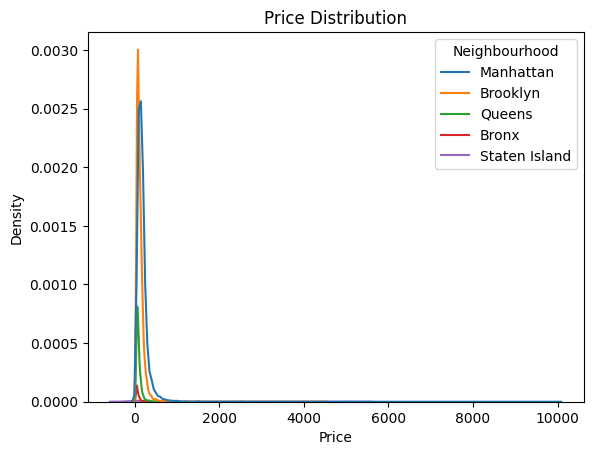

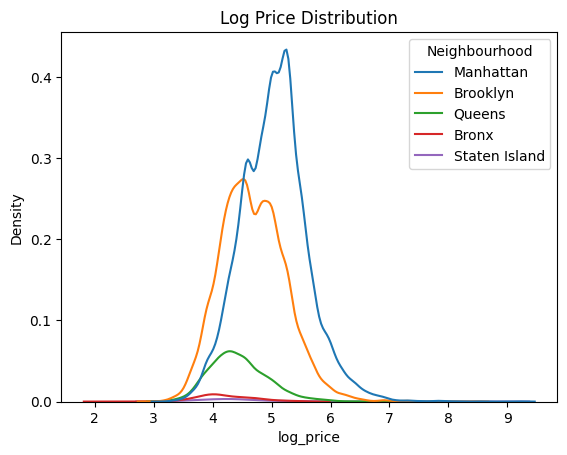

In [7]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# price KDE
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price Distribution")
plt.show()

# log price KDE
df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price Distribution")
plt.show()

2.2)
Price is skewed right (long tail)
Log(price) looks more normal and easier to compare

In [9]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:59:30   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

2.3) The intercept represents the average price in the baseline borough (Bronx), which is about $75.28.

Each coefficient shows how much more expensive a borough is compared to the Bronx. For example, Manhattan is about $108 more expensive, making it the most expensive borough on average. These coefficients match the group means from part 1, since each borough's average price equals the intercept plus its coefficient.

In [11]:
model2 = smf.ols("Price ~ Rating", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:00:24   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.8784     10.423      5.841      0.0

2.4) The slope coefficient on Rating is about 1.02, meaning that for each one-point increase in rating, the price increases by about $1 on average. This suggests that higher-rated properties tend to be slightly more expensive, although the effect is relatively small.

In [13]:
model3 = smf.ols("Price ~ C(Neighbourhood) + Rating", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        22:01:12   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

2.5) When adding both neighborhood and rating, the coefficient on Rating increases slightly from about 1.02 to 1.08. This means that after controlling for location, higher ratings are associated with slightly higher prices. The neighborhood coefficients remain very similar to before, showing that location is still the main factor affecting price differences across boroughs.

In [14]:
model4 = smf.ols("Price ~ C(Neighbourhood) * Rating", data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:01:28   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

2.6) When adding both neighborhood and rating, the coefficient on Rating increases slightly from about 1.02 to 1.08. This means that after controlling for location, higher ratings are associated with slightly higher prices. The neighborhood coefficients remain very similar to before, showing that location is still the main factor affecting price differences across boroughs.

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# prepare X and y
df_dummies = pd.get_dummies(df, columns=["Neighbourhood"], drop_first=True)

# Model 2: Rating only
X2 = df[["Rating"]]
y = df["Price"]

# Model 3: Rating + neighborhood
# Filter df_dummies to include only 'Rating' and the one-hot encoded 'Neighbourhood' columns
neighbourhood_dummy_cols = [col for col in df_dummies.columns if col.startswith('Neighbourhood_')]
X3 = df_dummies[neighbourhood_dummy_cols + ['Rating']]

# Model 4: interaction (manual version is messy, so keep simple comparison)

lr = LinearRegression()

print("Model 2 CV:", cross_val_score(lr, X2, y, cv=5).mean())
print("Model 3 CV:", cross_val_score(lr, X3, y, cv=5).mean())

Model 2 CV: 0.0014611836791742494
Model 3 CV: 0.050757126437275014


2.7) Using 5-fold cross validation, the model with only Rating had a very low score of about 0.0015, while the model with Neighbourhood and Rating had a higher score of about 0.0508. This shows that neighborhood is much more useful than rating for predicting price. Even so, the score is still fairly low, which suggests that these variables explain only a small part of the total variation in price.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


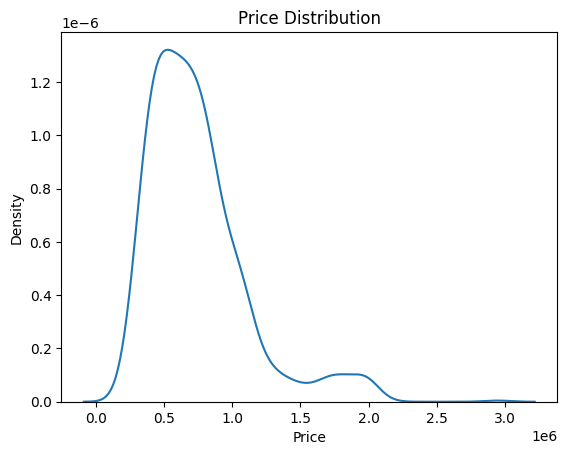

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


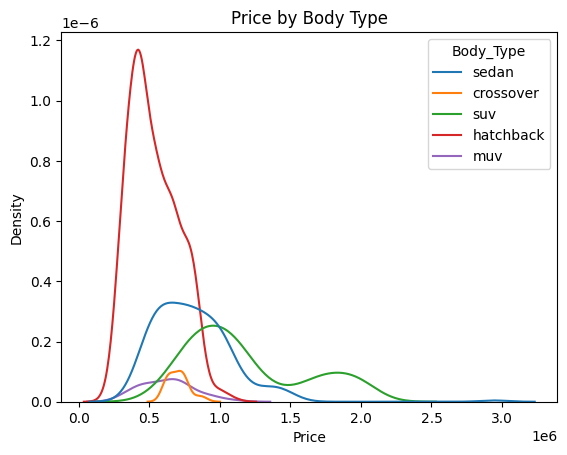

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cars_hw.csv")

# summary of price
print(df["Price"].describe())

# KDE plot
sns.kdeplot(data=df, x="Price")
plt.title("Price Distribution")
plt.show()

# grouped summary
group_summary = df.groupby("Body_Type")["Price"].describe()
print(group_summary)

# grouped KDE
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.title("Price by Body Type")
plt.show()

3.1) The price distribution is right-skewed, with most cars concentrated at lower prices and a long tail toward higher values. SUVs are the most expensive body type on average, with a mean price of about 1.18 million rupees. SUVs also have the highest variance, as shown by the largest standard deviation, indicating a wide spread in prices. Hatchbacks are the least expensive and have a tighter distribution, while sedans fall in between but still show relatively high variation.

In [18]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:27:52   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

3.2) The slope coefficient on Seating_Capacity is about 59,000, meaning that for each additional seat, the price increases by approximately 59,000 rupees on average. This suggests a positive relationship between seating capacity and price, although the low R-squared indicates that seating capacity alone does not explain much of the variation in price.

In [19]:
model2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000267
Time:                        22:28:25   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

When treating seating capacity as a categorical variable, the differences in price across seating levels are not consistent. For example, the jump from 5 to 6 seats is much larger than the others, while prices for 7 and 8 seats decrease relative to 6 seats. This shows that the relationship between seating capacity and price is not roughly linear, and a simple linear model does not fully capture the pattern.

In [20]:
df["Age"] = 2026 - df["Make_Year"]
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}

for k in range(1, 6):
    X = np.column_stack([df["Age"]**i for i in range(1, k+1)])
    y = df["Price"]

    model = LinearRegression()
    score = cross_val_score(model, X, y, cv=10).mean()

    results[k] = score

print(results)

{1: np.float64(0.2054391565742792), 2: np.float64(0.2045700162564402), 3: np.float64(0.20679554482905066), 4: np.float64(0.20072321783336283), 5: np.float64(0.19704777544091334)}


3.3) Using 10-fold cross validation, the model with 3 polynomial terms (Age, Age², and Age³) achieved the highest score. This suggests that a cubic relationship between age and price best fits the data. Adding more higher-order terms does not improve performance and may lead to overfitting.

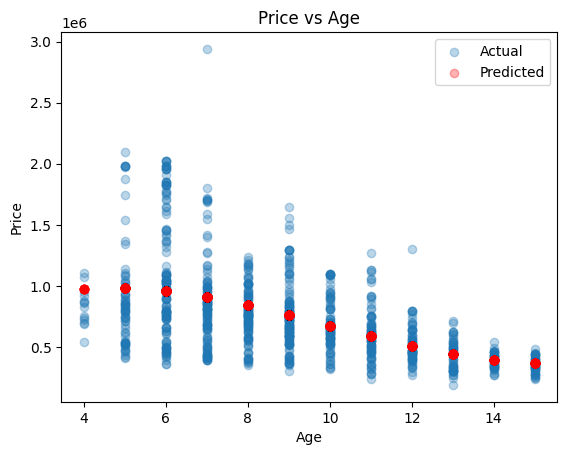

In [21]:
# pick best k (replace with your best)
k = max(results, key=results.get)

X = np.column_stack([df["Age"]**i for i in range(1, k+1)])
y = df["Price"]

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# plot
plt.scatter(df["Age"], y, alpha=0.3, label="Actual")
plt.scatter(df["Age"], y_pred, color="red", alpha=0.3, label="Predicted")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

3.4) The plot shows that price generally decreases as age increases, with a nonlinear downward trend. The model’s predicted values capture this overall pattern well, following a smooth curve. However, there is still a large spread in the actual data at each age, indicating that the model does not fully capture all the variation in price. Overall, the model fits the general relationship but is not highly precise.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [22]:
df = pd.read_csv("heart_hw.csv")

# proportions
control = df[df["transplant"] == "control"]["y"].mean()
treatment = df[df["transplant"] == "treatment"]["y"].mean()

ATE = treatment - control

print(control, treatment, ATE)

0.11764705882352941 0.34782608695652173 0.23017902813299232


4.1) The proportion of survival in the control group is 0.11764705882352941, and in the treatment group is 0.34782608695652173. The average treatment effect (ATE) is 0.23017902813299232, meaning that receiving a transplant changes the probability of surviving three years by this amount.

In [23]:
import statsmodels.formula.api as smf

model1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:40:38   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

4.2) The intercept from the regression is approximately 0.118, which matches the survival rate of the control group from part 1. The coefficient on transplant is approximately 0.230, which matches the average treatment effect (ATE). This shows that the regression correctly captures the difference in survival probabilities between the treatment and control groups.

In [24]:
model2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:40:54   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

4.3) After controlling for age, the coefficient on transplant increases from about 0.230 to 0.265, indicating that age was confounding the relationship between transplant and survival. The transplant coefficient now represents the effect of receiving a transplant while holding age constant. The age coefficient is negative, showing that survival probability decreases with age. This suggests that older patients are less likely to survive, and accounting for age reveals a stronger positive effect of the transplant.

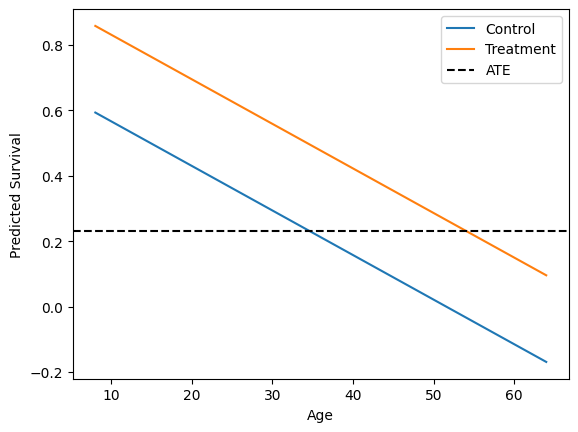

In [25]:
import numpy as np
import matplotlib.pyplot as plt

age_vals = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.predict(pd.DataFrame({
    "age": age_vals,
    "transplant": "control"
}))

pred_treatment = model2.predict(pd.DataFrame({
    "age": age_vals,
    "transplant": "treatment"
}))

plt.plot(age_vals, pred_control, label="Control")
plt.plot(age_vals, pred_treatment, label="Treatment")

plt.axhline(ATE, linestyle="--", color="black", label="ATE")

plt.legend()
plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.show()

4.4) The plot shows that survival decreases with age for both the control and treatment groups. The treatment group consistently has higher predicted survival than the control group. However, the constant ATE does not perfectly reflect the difference across ages. For younger patients, the ATE underestimates the benefit of a transplant, while for older patients, it overestimates the benefit. This indicates that the treatment effect varies with age, even though the model assumes a constant effect.

In [26]:
model3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:41:15   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Including the interaction term allows the effect of transplant to vary with age. The negative interaction coefficient indicates that the benefit of a transplant decreases as age increases. This means that younger patients experience a larger improvement in survival from a transplant, while older patients benefit less. This model better captures the pattern observed in the data compared to the model without interaction.

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df_dummies = pd.get_dummies(df, drop_first=True)

X1 = df_dummies[["transplant_treatment"]]
X2 = df_dummies[["transplant_treatment", "age"]]
X3 = df_dummies[["transplant_treatment", "age"]]
X3["interaction"] = X3["transplant_treatment"] * X3["age"]

y = df["y"]

lr = LinearRegression()

print("Model 1:", cross_val_score(lr, X1, y, cv=10).mean())
print("Model 2:", cross_val_score(lr, X2, y, cv=10).mean())
print("Model 3:", cross_val_score(lr, X3, y, cv=10).mean())

Model 1: -0.4043912290011423
Model 2: -0.4948327098378075
Model 3: -0.49098773603660933


/tmp/ipykernel_10539/2684131462.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X3["interaction"] = X3["transplant_treatment"] * X3["age"]


4.5) Using 10-fold cross validation, all models produced negative scores, indicating poor predictive performance. Among the models, the transplant-only model performed the best, while adding age and the interaction term did not improve accuracy. This suggests that although age and interaction effects are important for interpretation, they do not significantly improve prediction in this dataset.

4.6) A major concern is that this is observational data, so the treatment is not randomly assigned. Patients receiving transplants may differ systematically from those who do not, which can bias the estimated effects. Additionally, using this model to prioritize transplant access raises ethical concerns, as it may disadvantage certain groups or rely on incomplete predictors. The model also has limited predictive accuracy, so decisions based solely on it could be unreliable.